In [2]:
import sys
sys.path.append('../../')
from msBO.msBO import MultiStateBO
from msBO.objective import BPMvar_minimization
sys.path.append('../../../machineIO/')
from machineIO import construct_machineIO, VirtualMachineIO, StatefulOracleEvaluator
from machineIO.preset import get_limits

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from epics import caget, caget_many, caput_many
from phantasy import fetch_data
import datetime
from phantasy import ensure_set, fetch_data

# import importlib, msBO  # or from boom import msBO if that's your import
# importlib.reload(msBO)

In [3]:
n_init = 20
n_each = 4
n_iter = 3

In [4]:
SCS = caget("ACS_DIAG:DEST:ACTIVE_ION_SOURCE")
ion = caget("FE_ISRC"+str(SCS)+":BEAM:ELMT_BOOK")
Q = caget("FE_ISRC"+str(SCS)+":BEAM:Q_BOOK")
A = caget("FE_ISRC"+str(SCS)+":BEAM:A_BOOK")
# AQ = caget("FE_ISRC2:BEAM:MOVRQ_BOOK")
AQ = A/Q
ion = str(A)+ion+str(Q)
print('SCS'+str(SCS), ion, 'A/Q=',AQ)

SCS2 238U37 A/Q= 6.4324324324324325


In [5]:
now0 = datetime.datetime.now()
fname = now0.strftime('%Y%m%d_%H%M')+'['+ion+'][msBO]test'
fname

'20260418_1337[238U37][msBO]test'

### construct machineIO

In [6]:
mIO = construct_machineIO(ensure_set_timeout = 30, 
                          ensure_set_timewait_after_ramp = 0.3,
                          fetch_data_time_span = 2.0)

In [7]:
mIO.__dict__

{'_ensure_set_timeout': 30,
 '_ensure_set_timewait_after_ramp': 0.3,
 '_fetch_data_time_span': 2.0,
 '_sample_interval': 0.2,
 '_verbose': False,
 '_n_popup_ramping_issue': 0,
 '_history_lock': <unlocked _thread.lock object at 0x7f5c6ab64500>,
 'history': [],
 'test': False,
 'isOK_PVs': ['ACS_DIAG:CHP:STATE_RD'],
 'isOK_vals': [3],
 '_ensure_set': <machineIO.construct_machineIO._ensure_set_wrapper at 0x7f5c6abad190>,
 '_fetch_data': <machineIO.construct_machineIO._fetch_data_wrapper at 0x7f5dd064d550>}

In [11]:
ramping_time = 1
BO_comp_time = 4
n_state = 3
dt = mIO._ensure_set_timewait_after_ramp + mIO._fetch_data_time_span + ramping_time + BO_comp_time
print(f'expected run time: {int((n_init*n_state + n_iter*n_state*n_each)*dt/60)} min')
print(f'expected number of data: {n_init*n_state + n_iter*n_state*n_each}')

expected run time: 11 min
expected number of data: 96


### control knobs

In [12]:
control_CSETs = [
    'FS1_CSS:PSC2_D2351:I_CSET',
    'FS1_CSS:PSC1_D2351:I_CSET',
    'FS1_CSS:PSC2_D2381:I_CSET',
    'FS1_CSS:PSC1_D2381:I_CSET',
#     'FS1_BBS:PSC2_D2412:I_CSET',
#     'FS1_BBS:PSC1_D2412:I_CSET',
#     'FS1_BBS:PSC2_D2476:I_CSET',
#     'FS1_BBS:PSC1_D2476:I_CSET',
    'FS1_BBS:PSQ_D2416:I_CSET',
    'FS1_BBS:PSS_D2419:I_CSET',
    'FS1_BMS:PSC2_D2507:I_CSET',
    'FS1_BMS:PSC1_D2507:I_CSET',
#     'FS1_BMS:PSC2_D2534:I_CSET',
#     'FS1_BMS:PSC1_D2534:I_CSET',
]
control_RDs = [pv.replace('CSET','RD') for pv in control_CSETs]


control_ref = np.array(caget_many(control_CSETs))
control_rd_ref = np.array(caget_many(control_RDs))
control_tols_ref = 3*np.abs(control_ref - control_rd_ref)

control_tols = []
control_min = []
control_max = []
i = 0
for v, PV in zip(control_ref,control_CSETs):
    if ':PSC' in PV:
        control_min.append(v - 2)
        control_max.append(v + 2)
        control_tols.append(max(0.1,control_tols_ref[i]))
    elif ':PSQ_' in PV:
        control_min.append(v*0.97)
        control_max.append(v*1.03)
        control_tols.append(max(0.1,control_tols_ref[i]))
    elif ':PSS_' in PV:
        control_min.append(v*0.3)
        control_max.append(v*1.7)
        control_tols.append(max(0.05,control_tols_ref[i]))
    else:
        raise ValueError(f'control min/max cannot be determined automatically for {PV}')
    i+=1
        
        
##== Manually set decision bounds and tolerance
# control_min = [ -5, -5, -5, -5]
# control_max = [  5,  5,  5,  5]
# control_tols = [0.2,0.2,0.2,0.2]

assert len(control_CSETs) == len(control_min) == len(control_max) == len(control_tols)
control_Lo_limit, control_Hi_limit = get_limits(control_CSETs)
control_min = np.clip(control_min, a_min = control_Lo_limit, a_max = None)
control_max = np.clip(control_max, a_min = None, a_max = control_Hi_limit)
assert np.all(control_max > control_min)

pd.DataFrame(np.array([control_ref,control_min,control_max,control_tols,control_Lo_limit,control_Hi_limit]).T,
             index=control_CSETs, 
             columns=['current value','decision min','decision max','tol','LoLim','HiLim'])

,current value,decision min,decision max,tol,LoLim,HiLim
FS1_CSS:PSC2_D2351:I_CSET,1.45240,-0.547600,3.452400,0.10000,-39.0,39.0
FS1_CSS:PSC1_D2351:I_CSET,-1.96200,-3.962000,0.038000,0.10000,-19.0,19.0
FS1_CSS:PSC2_D2381:I_CSET,6.98800,4.988000,8.988000,0.10000,-39.0,39.0
FS1_CSS:PSC1_D2381:I_CSET,0.21000,-1.790000,2.210000,0.10000,-19.0,19.0
FS1_BBS:PSQ_D2416:I_CSET,177.66607,172.336088,182.996052,0.59721,0.0,265.0
FS1_BBS:PSS_D2419:I_CSET,1.80400,0.541200,3.066800,0.05000,0.0,4.7
FS1_BMS:PSC2_D2507:I_CSET,-5.00000,-7.000000,-3.000000,0.10000,-39.0,39.0
FS1_BMS:PSC1_D2507:I_CSET,0.12100,-1.879000,2.121000,0.15732,-19.0,19.0


In [13]:
control_couplings = {
    'FS1_BBS:PSQ_D2416:I_CSET':
        {
            'CSETs' :['FS1_BBS:PSQ_D2424:I_CSET','FS1_BBS:PSQ_D2463:I_CSET','FS1_BBS:PSQ_D2472:I_CSET'],
            'RDs'   :[],
            'tols'  :[],
            'coeffs':[],
        },
     'FS1_BBS:PSS_D2419:I_CSET':
        {
            'CSETs' :['FS1_BBS:PSS_D2469:I_CSET'],
            'RDs'   :[],
            'tols'  :[],
            'coeffs':[],
        },
}

for pv, val in control_couplings.items():
    x = caget(pv)
    y = np.array(caget_many(val['CSETs']))
    ipv = control_CSETs.index(pv)
    tol = control_tols[ipv]
    val['RDs'] = [pv.replace('CSET','RD') for pv in val['CSETs']]
    val['tols'] = [tol]*len(val['CSETs'])
    val['coeffs'] = y/x
    
control_couplings

{'FS1_BBS:PSQ_D2416:I_CSET': {'CSETs': ['FS1_BBS:PSQ_D2424:I_CSET',
   'FS1_BBS:PSQ_D2463:I_CSET',
   'FS1_BBS:PSQ_D2472:I_CSET'],
  'RDs': ['FS1_BBS:PSQ_D2424:I_RD',
   'FS1_BBS:PSQ_D2463:I_RD',
   'FS1_BBS:PSQ_D2472:I_RD'],
  'tols': [0.5972100000000182, 0.5972100000000182, 0.5972100000000182],
  'coeffs': array([0.44806062, 0.44806062, 1.        ])},
 'FS1_BBS:PSS_D2419:I_CSET': {'CSETs': ['FS1_BBS:PSS_D2469:I_CSET'],
  'RDs': ['FS1_BBS:PSS_D2469:I_RD'],
  'tols': [0.05],
  'coeffs': array([1.])}}

### state definition

In [14]:
state_CSETs  = ['FS1_BBS:CSEL_D2405:CTR_MTR.VAL']
state_RDs    = ['FS1_BBS:CSEL_D2405:CTR_MTR.RBV']
state_tols   = [0.1]*len(state_CSETs)
state_val0   = caget_many(state_CSETs)
state_key_vals  = {'74+':[  21.5],
                   '76+':[ - 1.0],
                   '78+':[ -24.0]}
states = list(state_key_vals.keys())
n_states = len(states)
state_key_vals

{'74+': [21.5], '76+': [-1.0], '78+': [-24.0]}

### monitors

In [15]:
# monitor_BPMs = ['FS1_BMS:BPM_D2502','FS1_BMS:BPM_D2537','FS1_BMS:BPM_D2587','FS1_BMS:BPM_D2600']
monitor_BPMs = ['FS1_BMS:BPM_D2502','FS1_BMS:BPM_D2537','FS1_BMS:BPM_D2587']
# monitor_BPMs = ['FS1_BMS:BPM_D2502','FS1_BMS:BPM_D2537']
monitor_RDs = []
for bpm in monitor_BPMs:
    monitor_RDs += [bpm+':XPOS_RD',bpm+':YPOS_RD',bpm+':MAG_RD']
#     monitor_RDs += [bpm+':YPOS_RD',bpm+':MAG_RD']

### Define Oracle 
# WARN!  This cell may change state!

In [16]:
bpm_posRDs = [pv for pv in monitor_RDs if 'POS_RD' in pv]
bpm_magRDs = [pv for pv in monitor_RDs if 'MAG_RD' in pv]

BPM_MAGs_ref = {}
for state, goal in state_key_vals.items():
#     ret = ensure_set(state_CSETs,state_RDs,goal,state_tols,timeout=30)
    input(f"{state_CSETs},{goal}")
    val, _ = fetch_data(bpm_magRDs,5)
    BPM_MAGs_ref[state] = val
# BPM_MAGs_ref = {
#     '28+': np.array([0.00736107, 0.00836198, 0.00703028]),
#     '29+': np.array([0.01749245, 0.01971336, 0.01654423])
# }
BPM_MAGs_ref

['FS1_BBS:CSEL_D2405:CTR_MTR.VAL'],[21.5]
[13:42:47.378] WARNING: phantasy.~.epics_tools: Established 3 PVs in 49.0 ms.
['FS1_BBS:CSEL_D2405:CTR_MTR.VAL'],[-1.0]
[13:43:25.279] WARNING: phantasy.~.epics_tools: Established 3 PVs in 0.1 ms.
['FS1_BBS:CSEL_D2405:CTR_MTR.VAL'],[-24.0]
[13:44:10.544] WARNING: phantasy.~.epics_tools: Established 3 PVs in 0.1 ms.


{'74+': array([0.0091234 , 0.01041684, 0.00873437]),
 '76+': array([0.00750332, 0.0085541 , 0.00719208]),
 '78+': array([0.00186837, 0.0021309 , 0.00178762])}

In [17]:
def BPM_MAG_obj(df,s):
    df['BPM:MAG_min_ratio'] = (df[bpm_magRDs].values/BPM_MAGs_ref[s][None,:]).min()
    return df

In [18]:
oracle_key_names = {'x':control_RDs,
                    'y':bpm_posRDs + ['BPM:MAG_min_ratio']}
oracle_key_names

{'x': ['FS1_CSS:PSC2_D2351:I_RD',
  'FS1_CSS:PSC1_D2351:I_RD',
  'FS1_CSS:PSC2_D2381:I_RD',
  'FS1_CSS:PSC1_D2381:I_RD',
  'FS1_BBS:PSQ_D2416:I_RD',
  'FS1_BBS:PSS_D2419:I_RD',
  'FS1_BMS:PSC2_D2507:I_RD',
  'FS1_BMS:PSC1_D2507:I_RD'],
 'y': ['FS1_BMS:BPM_D2502:XPOS_RD',
  'FS1_BMS:BPM_D2502:YPOS_RD',
  'FS1_BMS:BPM_D2537:XPOS_RD',
  'FS1_BMS:BPM_D2537:YPOS_RD',
  'FS1_BMS:BPM_D2587:XPOS_RD',
  'FS1_BMS:BPM_D2587:YPOS_RD',
  'BPM:MAG_min_ratio']}

### check control couplings 

In [19]:
oracleEvaluator = StatefulOracleEvaluator(
    mIO,
    control_CSETs= control_CSETs,
    control_RDs  = control_RDs,
    control_tols = control_tols,
    state_CSETs  = state_CSETs,
    state_RDs    = state_RDs,
    state_tols   = state_tols,
    state_key_vals = state_key_vals,
    oracle_key_names = oracle_key_names,
    monitor_RDs  = monitor_RDs,
    control_couplings = control_couplings,
    state_df_manipulators = [BPM_MAG_obj],
)

# Define Composite Object

In [20]:
n_state = len(states)
n_task = len(bpm_posRDs)+1
composite_objective_function = BPMvar_minimization(S=n_state, J=n_task)

# Define msBO

In [21]:
local_optimization = False
acq_type = 'EI'
fix_acq_state = False

msbo = MultiStateBO(
    states = states,
    tasks  = oracle_key_names['y'], 
    control_min = control_min,
    control_max = control_max,
    multistate_oracle_evaluator = oracleEvaluator,
    composite_objective_function = composite_objective_function,
    local_bound_size = 0.2*(np.asarray(control_max) - np.asarray(control_min))
    )

[13:44:49.271] WARNING: phantasy.~.epics_tools: Established 36 PVs in 53.6 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


# run msBO

set FS1_BBS:CSEL_D2405:CTR_MTR.VAL to 21.5
[13:45:36.866] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[13:45:44.303] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[13:45:54.619] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


...

/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:17:04.925] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:17:13.340] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


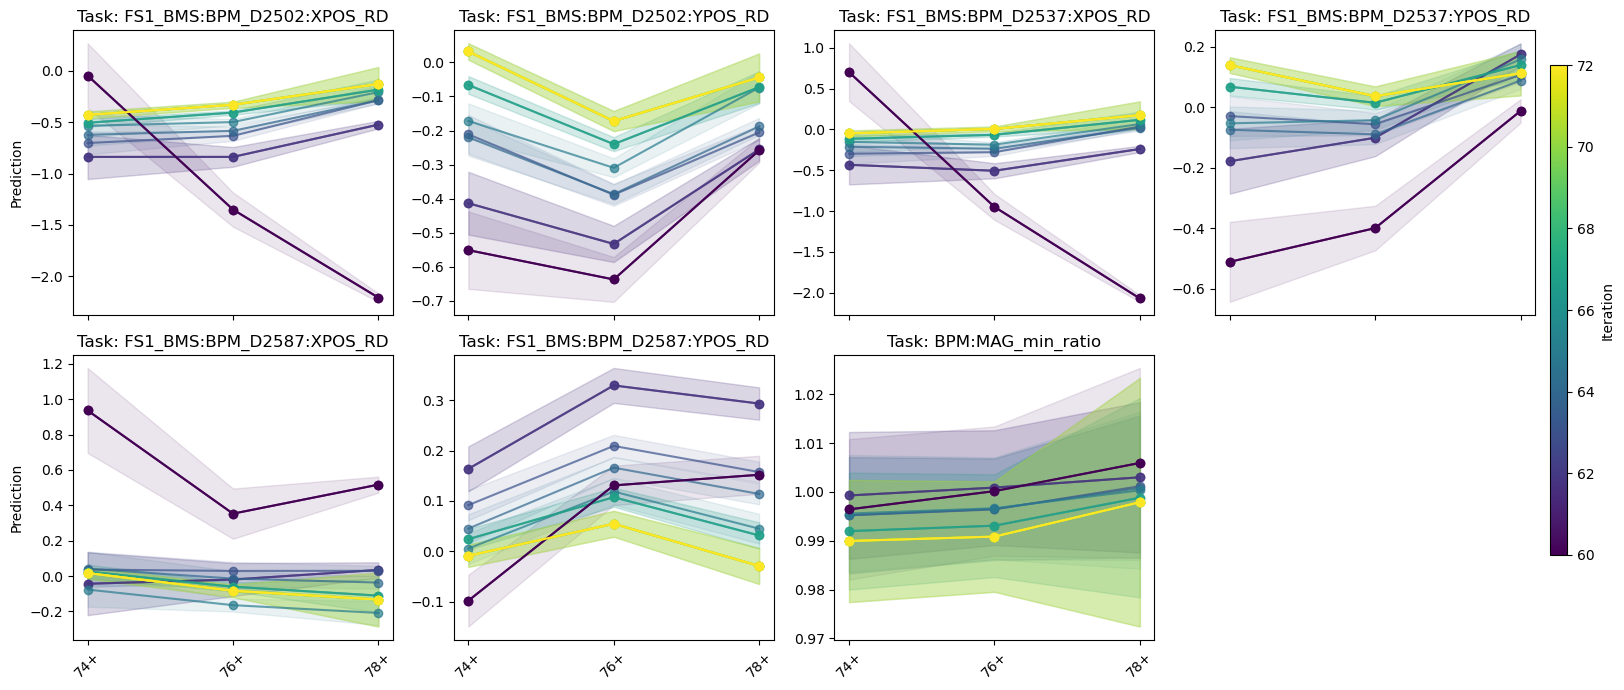

1 74+


[14:17:52.621] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:18:32.227] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


...

/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:25:55.647] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:26:09.707] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


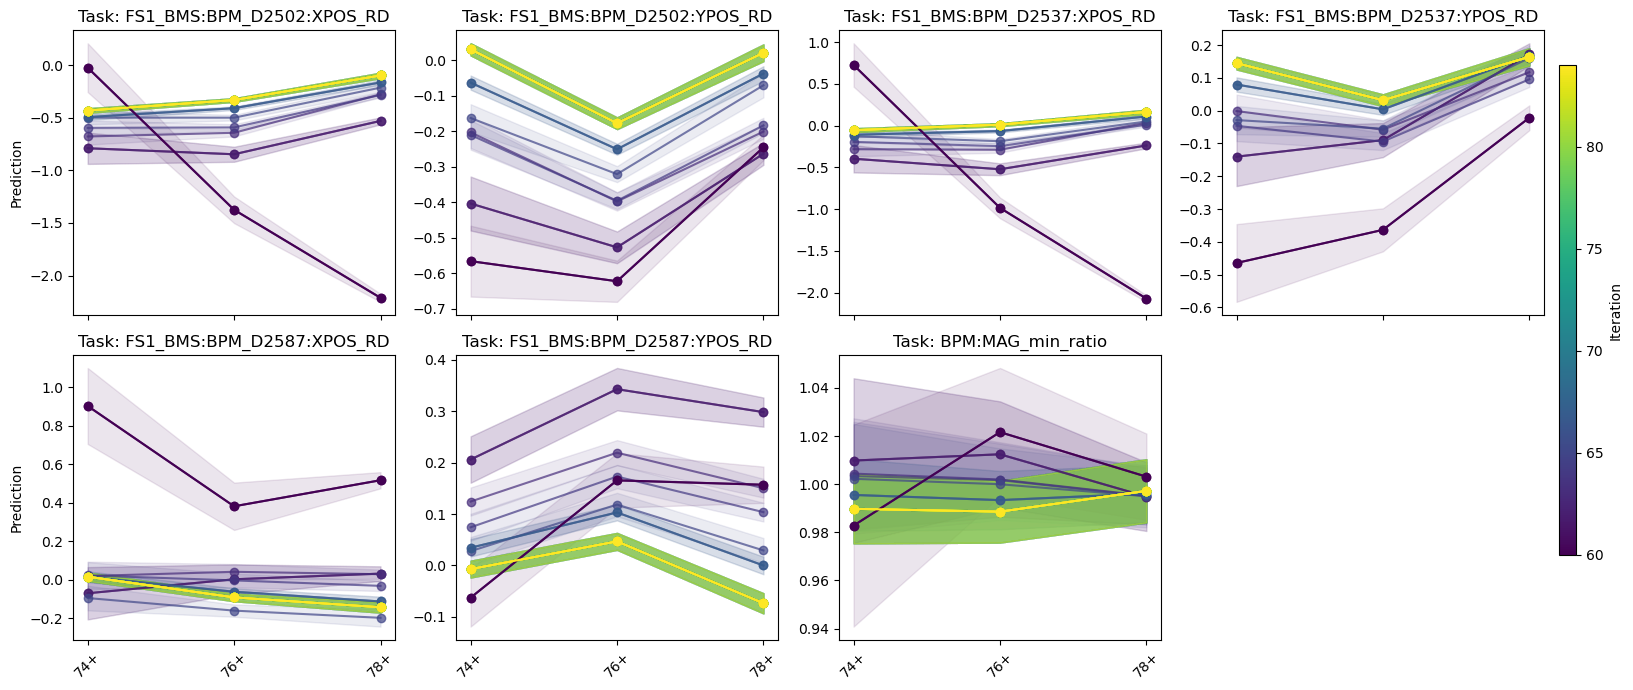

2 78+
[14:26:23.090] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:27:05.450] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:27:46.931] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


...

/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:34:29.621] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


[14:35:14.528] WARNING: phantasy.~.epics_tools: Established 36 PVs in 0.1 ms.


/user/shared/pkgs/msBO/examples/[20260418][238U]/../../../machineIO/machineIO/construct_machineIO.py:182: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  while np.any(df[self.isOK_PVs].mean().values != self.isOK_vals):


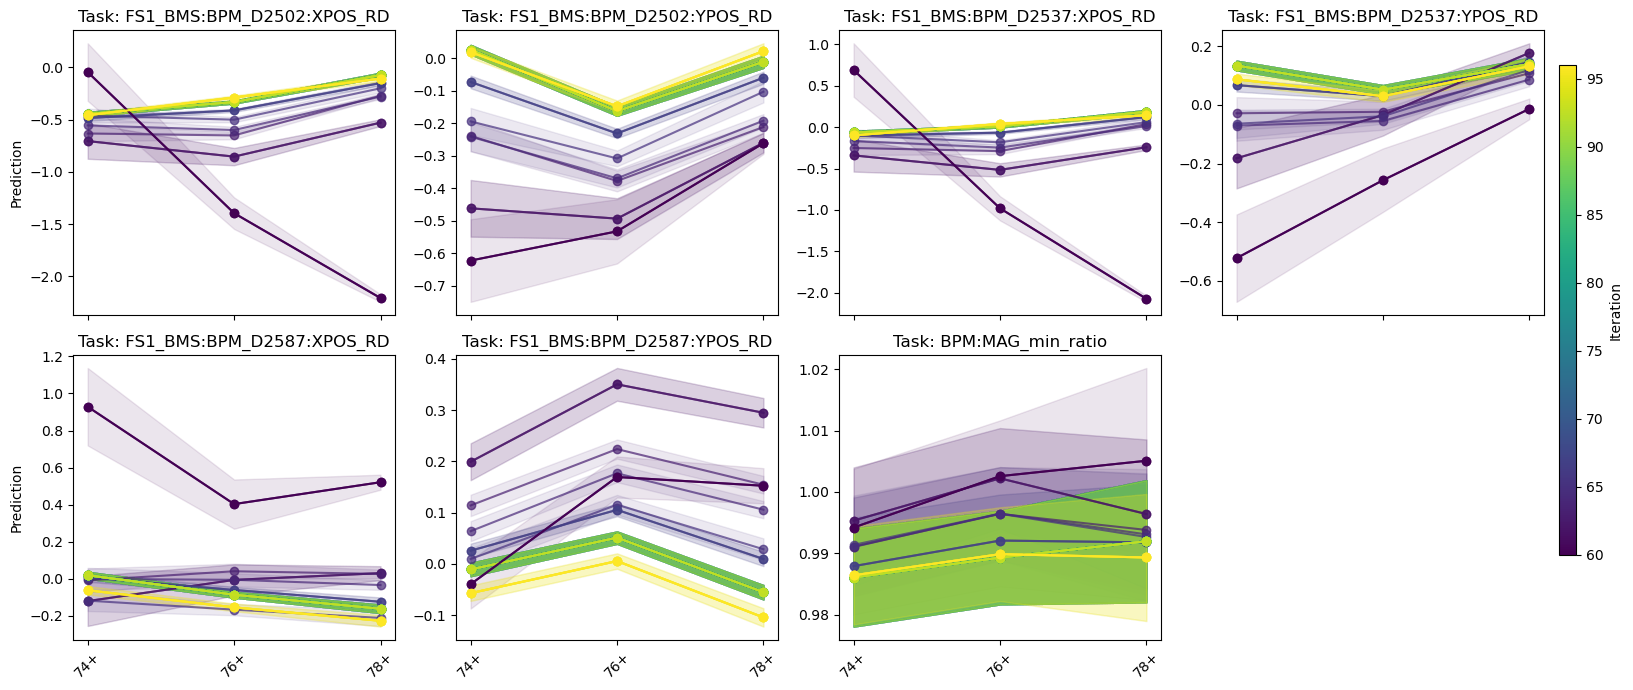

In [22]:
msbo.init(n_init=n_init, local_optimization=local_optimization)
for i_iter in range(n_iter):
    if i_iter%2==0:
        states_order = states[::-1]
    else:
        states_order = states
    for s in states_order:
        print(i_iter, s)
        for i_each in range(n_each):
            msbo.step(s=s, local_optimization=local_optimization, acq_type=acq_type, fix_acq_state=fix_acq_state)
    fig, axes = msbo.plot_state_predictions_history()
    plt.show()

In [ ]:
now1 = datetime.datetime.now()
timedelta = now1-now0
timedelta

### visualize optimization result

In [ ]:
fig,ax, virtualObjMean = msbo.plot_composite_objective()
ax[0].set_ylim(0.9,1)

In [ ]:
fig, axes = msbo.plot_state_predictions_history()

### set to best solution

In [ ]:
from epics import caput_many, caget_many

x_best = msbo.history['predictions'][-1]['x_best']
caput_many(control_CSETs,x_best)

### restore states

In [ ]:
caput_many(state_CSETs,state_val0)

### restore control if optimization result is not good

In [ ]:
# caput_many(control_CSETs,control_ref)